# How ML Model Prediction Actually Works — From Scratch

This notebook exists to remove the "magic" from `model.predict(x)`.

By the end you will have **built, by hand, with plain NumPy**:

1. A **Linear Regression** model (regression)
2. A **Logistic Regression** model (classification)
3. A tiny **Neural Network** (non-linear model)

For each one you will see:

- the exact math that defines a *prediction*
- how *training* finds the parameters that go into that math
- a clean, minimal `predict()` function you could show a teammate to explain "this is literally all inference is"

**Core idea to hold onto the whole time:**

> A trained ML model is just a **function `f(x; θ)`** — data `x` in, parameters `θ` (learned numbers) baked in, prediction `ŷ` out.
> *Training* is the (expensive, iterative) process of searching for good `θ`.
> *Prediction / inference* is just **plugging numbers into `f`** — one forward pass, no learning, no iteration.

Everything below is designed to make that distinction concrete and impossible to un-see.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)


## Part 1 — Linear Regression from Scratch

### 1.1 The model (this IS the prediction step)

For an input vector $x = [x_1, x_2, ..., x_n]$, linear regression predicts:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = w^T x + b$$

That's it. That whole equation is "the model." Once you know $w$ (weights) and $b$ (bias), predicting is one dot product.

### 1.2 How training finds $w, b$

We don't know $w, b$ yet. We find them by:

1. **Defining a loss** — how wrong are the current predictions? For regression we use Mean Squared Error:
$$J(w,b) = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2$$

2. **Computing the gradient** — the direction that increases the loss fastest:
$$\frac{\partial J}{\partial w} = \frac{2}{m}X^T(\hat{y}-y), \qquad \frac{\partial J}{\partial b} = \frac{2}{m}\sum(\hat{y}-y)$$

3. **Gradient descent** — nudge the parameters a little *against* the gradient, repeat:
$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}, \qquad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Let's generate some synthetic data first so we have ground truth to check against.


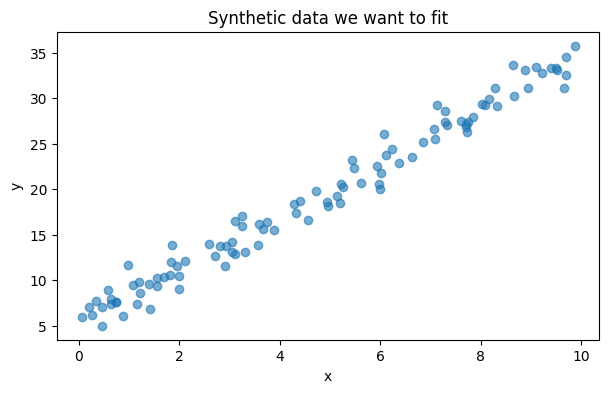

In [2]:
# Synthetic data: y = 3x + 5 + noise
m = 100  # number of samples
X = np.random.rand(m, 1) * 10          # shape (100, 1)
true_w, true_b = 3.0, 5.0
y = true_w * X[:, 0] + true_b + np.random.randn(m) * 1.5

plt.scatter(X, y, alpha=0.6)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Synthetic data we want to fit")
plt.show()


In [3]:
class LinearRegressionScratch:
    """Linear regression implemented with nothing but NumPy."""

    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def predict(self, X):
        # ***** THIS is the entire prediction step *****
        # one matrix multiply + one addition. No loops, no learning.
        return X @ self.w + self.b

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)   # start params at 0 (any init works)
        self.b = 0.0

        for i in range(self.n_iters):
            y_pred = self.predict(X)                     # forward pass
            error = y_pred - y

            # gradients of MSE loss w.r.t. w and b
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)

            # gradient descent update
            self.w -= self.lr * dw
            self.b -= self.lr * db

            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

        return self


model = LinearRegressionScratch(lr=0.02, n_iters=500)
model.fit(X, y)

print(f"Learned w = {model.w[0]:.3f}  (true w = {true_w})")
print(f"Learned b = {model.b:.3f}  (true b = {true_b})")


Learned w = 2.934  (true w = 3.0)
Learned b = 5.305  (true b = 5.0)


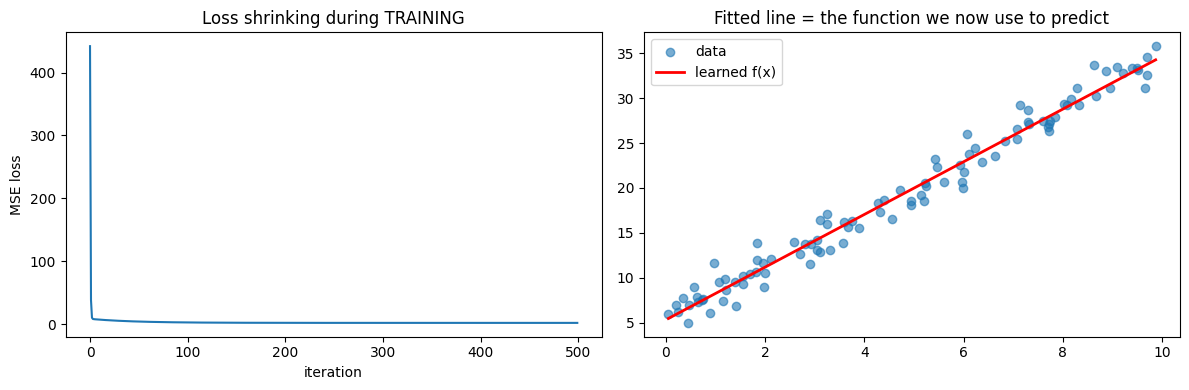

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(model.loss_history)
axes[0].set_title("Loss shrinking during TRAINING")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("MSE loss")

axes[1].scatter(X, y, alpha=0.6, label="data")
x_line = np.array([[X.min()], [X.max()]])
axes[1].plot(x_line, model.predict(x_line), color="red", linewidth=2, label="learned f(x)")
axes[1].set_title("Fitted line = the function we now use to predict")
axes[1].legend()
plt.tight_layout(); plt.show()


### 1.3 Watching a *single* prediction happen, step by step

This is the part people usually never see explicitly: once `model.fit()` is done, `w` and `b` are just two fixed numbers sitting in memory. A prediction on a brand-new point is nothing more than arithmetic.


In [5]:
x_new = np.array([[7.5]])   # a brand new, never-seen-during-training input

w, b = model.w[0], model.b
manual_prediction = w * x_new[0, 0] + b

print(f"w (learned)      = {w:.4f}")
print(f"b (learned)      = {b:.4f}")
print(f"x_new            = {x_new[0,0]}")
print(f"manual  w*x + b  = {manual_prediction:.4f}")
print(f"model.predict()  = {model.predict(x_new)[0]:.4f}")
print("\n^ Notice these two numbers match exactly. predict() has no hidden steps.")


w (learned)      = 2.9338
b (learned)      = 5.3046
x_new            = 7.5
manual  w*x + b  = 27.3081
model.predict()  = 27.3081

^ Notice these two numbers match exactly. predict() has no hidden steps.


### 1.4 Sanity check against scikit-learn

If our from-scratch math is right, `sklearn`'s optimized (closed-form) solution should land on essentially the same $w, b$.


In [6]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X, y)

print(f"sklearn w = {sk_model.coef_[0]:.3f}, b = {sk_model.intercept_:.3f}")
print(f"scratch w = {model.w[0]:.3f}, b = {model.b:.3f}")


sklearn w = 2.931, b = 5.323
scratch w = 2.934, b = 5.305


---
## Part 2 — Logistic Regression from Scratch (Classification)

Linear regression predicts a number. For a **yes/no** style prediction we need output squashed into $[0, 1]$ so it can be read as a probability.

### 2.1 The model

$$z = w^T x + b \qquad \hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

$\sigma$ (the **sigmoid**) is the only new ingredient vs. linear regression. The prediction pipeline is:

`raw score z` → `sigmoid squashes to a probability` → `threshold at 0.5 gives a class`

### 2.2 Training

Instead of MSE we minimize **binary cross-entropy**:
$$J(w,b) = -\frac{1}{m}\sum \Big[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\Big]$$

The elegant part: the gradient has the *exact same shape* as linear regression's —
$$\frac{\partial J}{\partial w} = \frac{1}{m}X^T(\hat{y}-y)$$
Only the forward pass (adding the sigmoid) changed.


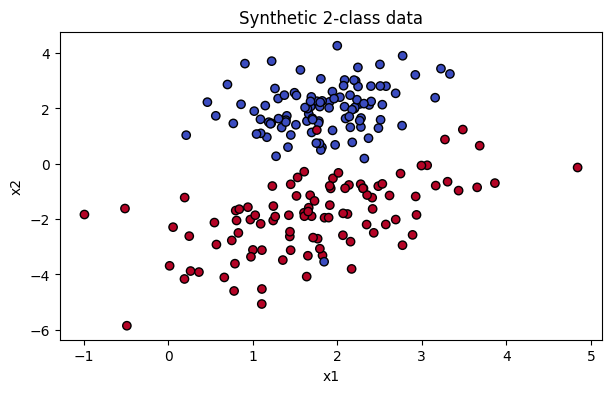

In [7]:
from sklearn.datasets import make_classification

Xc, yc = make_classification(n_samples=200, n_features=2, n_redundant=0,
                              n_clusters_per_class=1, class_sep=1.8, random_state=1)

plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k")
plt.title("Synthetic 2-class data"); plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


In [8]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iters=2000):
        self.lr = lr
        self.n_iters = n_iters
        self.loss_history = []

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    def predict_proba(self, X):
        # ***** the entire prediction step: linear score -> sigmoid *****
        z = X @ self.w + self.b
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0

        for _ in range(self.n_iters):
            y_pred = self.predict_proba(X)          # forward pass
            error = y_pred - y

            dw = (1 / n_samples) * (X.T @ error)     # same gradient shape as linear regression!
            db = (1 / n_samples) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            eps = 1e-9  # avoid log(0)
            loss = -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))
            self.loss_history.append(loss)
        return self


clf = LogisticRegressionScratch(lr=0.5, n_iters=3000)
clf.fit(Xc, yc)
acc = (clf.predict(Xc) == yc).mean()
print(f"Training accuracy: {acc:.2%}")


Training accuracy: 98.00%


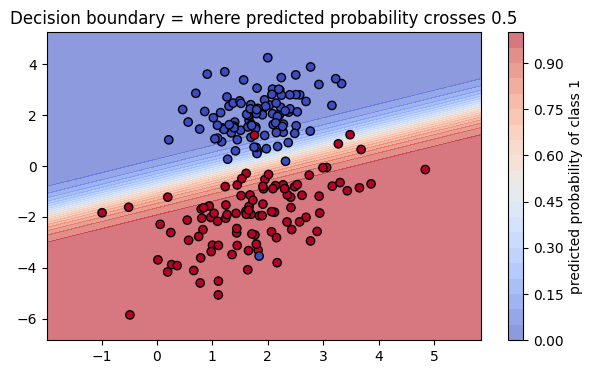

In [9]:
# Visualize the decision boundary the model learned
xx, yy = np.meshgrid(np.linspace(Xc[:,0].min()-1, Xc[:,0].max()+1, 200),
                      np.linspace(Xc[:,1].min()-1, Xc[:,1].max()+1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf.predict_proba(grid).reshape(xx.shape)

plt.contourf(xx, yy, probs, levels=20, cmap="coolwarm", alpha=0.6)
plt.colorbar(label="predicted probability of class 1")
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k")
plt.title("Decision boundary = where predicted probability crosses 0.5")
plt.show()


In [10]:
# One prediction, fully manual, so nothing is hidden
x_new = np.array([1.0, 0.5])
z = x_new @ clf.w + clf.b
p = 1 / (1 + np.exp(-z))
print(f"z (raw score)        = {z:.4f}")
print(f"sigmoid(z) = P(y=1)  = {p:.4f}")
print(f"predicted class      = {int(p >= 0.5)}")
print(f"clf.predict()        = {clf.predict(x_new.reshape(1,-1))[0]}")


z (raw score)        = -2.0903
sigmoid(z) = P(y=1)  = 0.1100
predicted class      = 0
clf.predict()        = 0


---
## Part 3 — A Tiny Neural Network from Scratch

Linear/logistic regression can only draw a **straight** decision boundary. A neural network stacks layers to bend that boundary into curves.

### 3.1 The model (forward pass = prediction)

A 2-layer network (1 hidden layer):

$$z^{[1]} = XW^{[1]} + b^{[1]}, \qquad a^{[1]} = \tanh(z^{[1]})$$
$$z^{[2]} = a^{[1]}W^{[2]} + b^{[2]}, \qquad \hat{y} = \sigma(z^{[2]})$$

That's the **entire prediction procedure** — two linear steps, two non-linearities, done. Everything below this cell is just *how do we find good $W^{[1]}, b^{[1]}, W^{[2]}, b^{[2]}$*, i.e. training.

### 3.2 Training = backpropagation

Backprop is just the chain rule, applied layer by layer, computing how much each parameter contributed to the final loss, then nudging it with gradient descent — same update rule as before, just more parameters.

We'll fit it on a data shape a straight line genuinely cannot separate (two interleaving "moons"), to make the payoff of the non-linearity obvious.


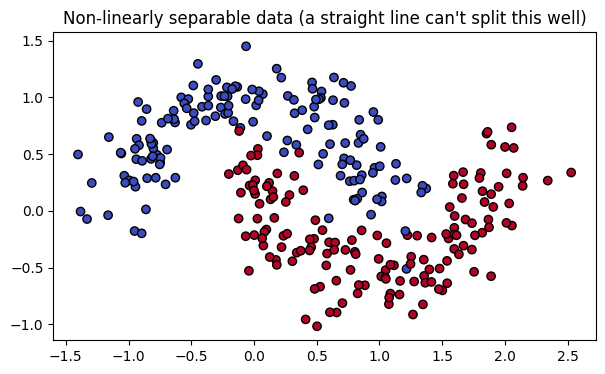

In [11]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=0)

plt.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", edgecolor="k")
plt.title("Non-linearly separable data (a straight line can't split this well)")
plt.show()


In [12]:
class TinyNeuralNet:
    """A single-hidden-layer neural network, fully from scratch."""

    def __init__(self, n_input, n_hidden, lr=0.5, n_iters=5000):
        self.lr = lr
        self.n_iters = n_iters
        rng = np.random.default_rng(0)
        # small random init -- breaks symmetry between hidden units
        self.W1 = rng.standard_normal((n_input, n_hidden)) * 0.5
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.standard_normal((n_hidden, 1)) * 0.5
        self.b2 = np.zeros(1)
        self.loss_history = []

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        # ***** THIS ENTIRE METHOD is what "prediction" means for a neural net *****
        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.tanh(self.z1)                 # hidden layer activation
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)             # output probability
        return self.a2

    def predict_proba(self, X):
        return self.forward(X).ravel()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def backward(self, X, y):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        # ---- output layer gradients ----
        dz2 = self.a2 - y                            # (m,1)
        dW2 = self.a1.T @ dz2 / m
        db2 = np.sum(dz2, axis=0) / m

        # ---- hidden layer gradients (chain rule through tanh) ----
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (1 - self.a1 ** 2)                # derivative of tanh
        dW1 = X.T @ dz1 / m
        db1 = np.sum(dz1, axis=0) / m

        # ---- gradient descent update, same rule as every model above ----
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y):
        for _ in range(self.n_iters):
            y_pred = self.forward(X)
            eps = 1e-9
            loss = -np.mean(y * np.log(y_pred.ravel() + eps) +
                             (1 - y) * np.log(1 - y_pred.ravel() + eps))
            self.loss_history.append(loss)
            self.backward(X, y)
        return self


nn = TinyNeuralNet(n_input=2, n_hidden=8, lr=0.8, n_iters=4000)
nn.fit(Xm, ym)
acc = (nn.predict(Xm) == ym).mean()
print(f"Training accuracy: {acc:.2%}")


Training accuracy: 98.33%


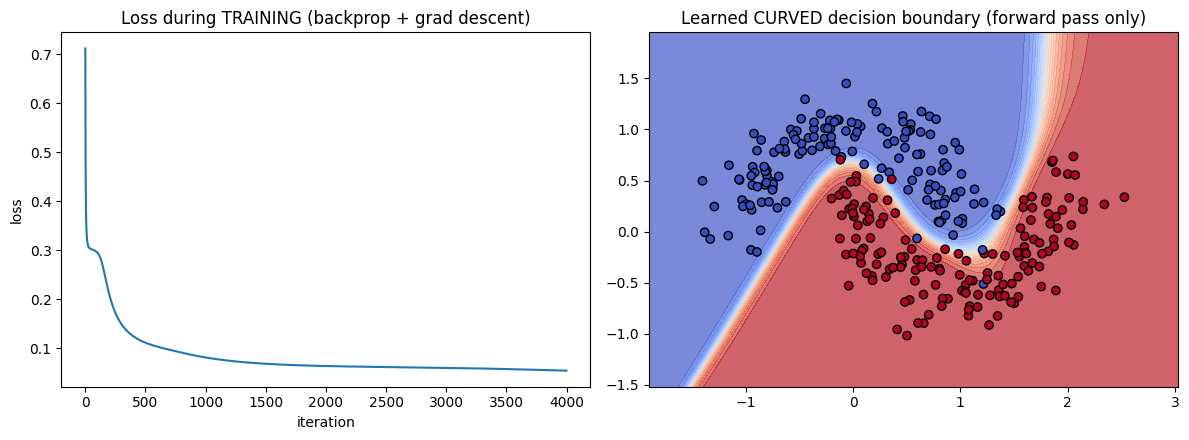

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(nn.loss_history)
axes[0].set_title("Loss during TRAINING (backprop + grad descent)")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("loss")

xx, yy = np.meshgrid(np.linspace(Xm[:,0].min()-0.5, Xm[:,0].max()+0.5, 300),
                      np.linspace(Xm[:,1].min()-0.5, Xm[:,1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = nn.predict_proba(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, probs, levels=20, cmap="coolwarm", alpha=0.7)
axes[1].scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", edgecolor="k")
axes[1].set_title("Learned CURVED decision boundary (forward pass only)")
plt.tight_layout(); plt.show()


---
## Part 4 — The Big Picture: Training vs. Prediction

Look back at all three models. In every single case, the story was identical:

| Step | What happens | Cost |
|---|---|---|
| **Training** (`fit`) | Search for parameters that minimize a loss, via many iterations of forward pass → compute loss → compute gradient → update parameters | Expensive, done once (or occasionally) |
| **Prediction** (`predict`) | ONE forward pass through the already-learned function, using fixed parameters | Cheap, done every time you serve a request |

This is exactly what's happening inside `sklearn`'s `.predict()`, PyTorch/TensorFlow's `.forward()` / `model(x)`, and any production inference server — just with:
- more layers,
- more clever architectures (convolutions, attention, etc. — still "linear step + non-linearity" repeated),
- highly optimized/parallelized matrix math (GPUs, BLAS) instead of our simple NumPy loop.

**No matter how large the model is, the pattern never changes:** parameters are learned once during training, then predictions are pure, deterministic function evaluation.


In [14]:
def minimal_predict_function(x, w, b):
    """
    This is, quite literally, all a deployed linear/logistic model does at
    inference time. Everything else in an ML system (data pipelines, feature
    engineering, model registries, serving infra) exists to get clean `x` in
    and get `w, b` (the trained parameters) loaded correctly.
    """
    z = np.dot(w, x) + b
    return z  # or sigmoid(z) for classification

# Reusing the linear regression parameters we trained earlier:
print(minimal_predict_function(np.array([7.5]), model.w, model.b))


27.308147993820846


## Part 5 — Practical Takeaways (for you as an ML engineer / researcher)

- **Debugging a bad prediction?** Check, in order: (1) is the input preprocessed the *same way* as training data (scaling, encoding)? (2) are you loading the *correct, fully-trained* parameters? (3) does the forward-pass code match what was used at training time (same architecture)? Most "the model gives weird outputs in production" bugs are (1) or (2), not the model itself.
- **`model.eval()` / inference mode** in frameworks like PyTorch exists because some layers (dropout, batch norm) *behave differently* in training vs. prediction — another reason it's worth being crisp about which mode you're in.
- **Latency at inference** is dominated by the forward pass cost (matrix multiplies), which is why techniques like quantization, distillation, and pruning — all things you'll meet as an ML engineer — exist to shrink that one forward pass, not the training loop.
- **When researching new architectures**, you're almost always inventing a new `forward()` (how prediction is computed) and letting autodiff handle `backward()` for you — but understanding the manual backward pass above is exactly what lets you debug when autodiff-based training doesn't converge.

### Exercises to go further
1. Add L2 regularization to `LinearRegressionScratch` and watch how `w` shrinks.
2. Extend `TinyNeuralNet` to a second hidden layer.
3. Swap `tanh` for `ReLU` and rederive the backward pass by hand.
4. Replace gradient descent with mini-batch SGD and compare convergence speed.
